In [16]:
# Import libraries

import numpy as np

import matplotlib.pyplot as plt

from sklearn import datasets

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score

from sklearn.metrics import classification_report, confusion_matrix

In [17]:
# Load dataset
iris = datasets.load_iris()
X = iris.data[:, :2]   # first two features for visualization
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# SVM kernel
kernels = {
    "linear": SVC(kernel="linear", C=1.0),
}

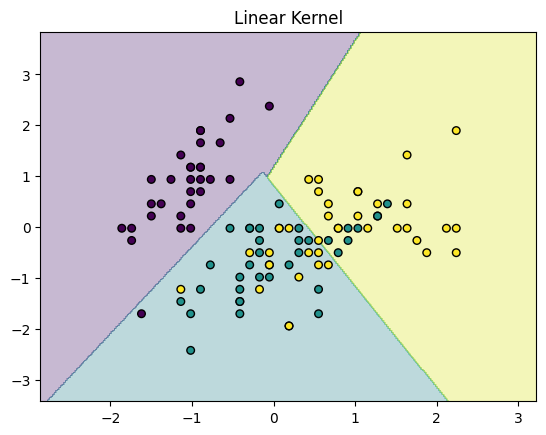

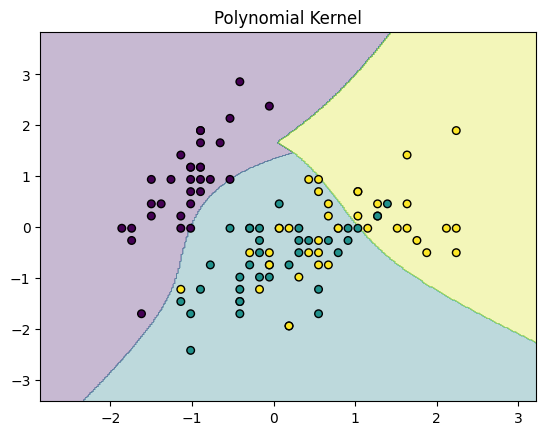

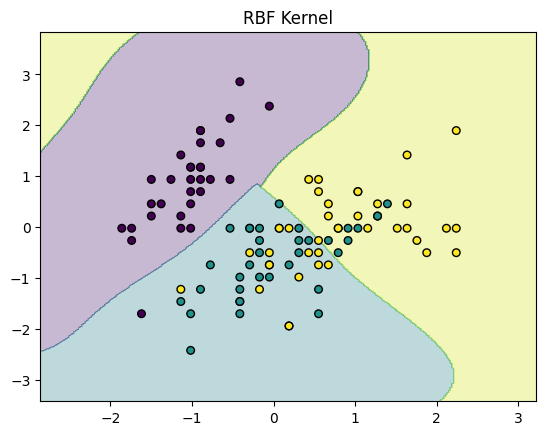

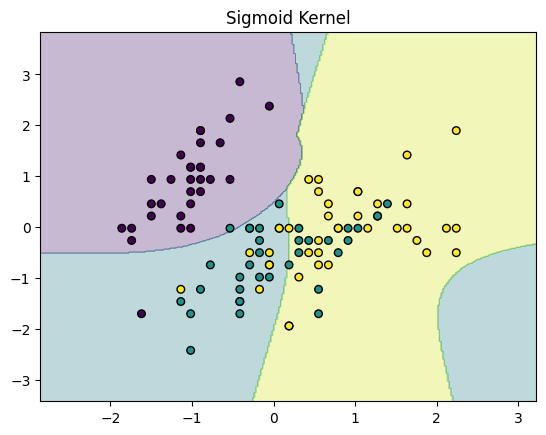

Accuracy Results:
{'Linear': 0.7333333333333333, 'Polynomial': 0.7555555555555555, 'RBF': 0.7333333333333333, 'Sigmoid': 0.7777777777777778}


In [18]:
# Define kernels
kernels = {
    "Linear": SVC(kernel="linear", C=1.0),
    "Polynomial": SVC(kernel="poly", degree=3, C=1.0),
    "RBF": SVC(kernel="rbf", gamma='scale', C=1.0),
    "Sigmoid": SVC(kernel="sigmoid", C=1.0)
}

# Plot function
def plot_svm(X, y, model, title):

    h = 0.02

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, edgecolors='k')
    plt.title(title)
    plt.show()


# Train and compare
accuracy_results = {}

for name, model in kernels.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    accuracy_results[name] = acc

    plot_svm(X_train, y_train, model, f"{name} Kernel")


print("Accuracy Results:")
print(accuracy_results)

In [19]:
# Show accuracy comparison
print("Kernel Accuracy Comparison:")

for k, v in accuracy_results.items():
    print(f"{k} Kernel Accuracy: {v:.2f}")

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Kernel Accuracy Comparison:
Linear Kernel Accuracy: 0.73
Polynomial Kernel Accuracy: 0.76
RBF Kernel Accuracy: 0.73
Sigmoid Kernel Accuracy: 0.78
Confusion Matrix:
 [[19  0  0]
 [ 1  5  7]
 [ 0  2 11]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       0.71      0.38      0.50        13
           2       0.61      0.85      0.71        13

    accuracy                           0.78        45
   macro avg       0.76      0.74      0.73        45
weighted avg       0.78      0.78      0.76        45

